In [39]:
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch import onnx
import matplotlib.pyplot as plt


In [40]:
BOARD_SIZE = 5
K = 4  # four in a row


def has_four_in_a_row(board):
    # Rows
    for r in range(BOARD_SIZE):
        for c in range(BOARD_SIZE - K + 1):
            w = board[r, c:c+K]
            if abs(w.sum()) == K:
                return True

    # Columns
    for c in range(BOARD_SIZE):
        for r in range(BOARD_SIZE - K + 1):
            w = board[r:r+K, c]
            if abs(w.sum()) == K:
                return True

    # Diagonal \
    for r in range(BOARD_SIZE - K + 1):
        for c in range(BOARD_SIZE - K + 1):
            w = np.array([board[r+i, c+i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    # Diagonal /
    for r in range(BOARD_SIZE - K + 1):
        for c in range(K - 1, BOARD_SIZE):
            w = np.array([board[r+i, c-i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    return False

def action_to_index(row, col, symbol):
    sym = 0 if symbol == 1 else 1
    return row * 10 + col * 2 + sym

def index_to_action(idx):
    row = idx // 10
    col = (idx % 10) // 2
    symbol = 1 if idx % 2 == 0 else -1
    return row, col, symbol

def encode_state(board, current_player):
    x_plane = (board == 1).astype(np.float32)
    o_plane = (board == -1).astype(np.float32)
    empty_plane = (board == 0).astype(np.float32)
    turn_plane = np.ones_like(board, dtype=np.float32) \
        if current_player == 1 else np.zeros_like(board, dtype=np.float32)

    return np.stack([x_plane, o_plane, empty_plane, turn_plane], axis=0)



In [41]:
#test call

# Horizontal
b = np.zeros((5,5), dtype=int)
b[2, 0:4] = 1
assert has_four_in_a_row(b)

# Vertical
b = np.zeros((5,5), dtype=int)
b[0:4, 3] = -1
assert has_four_in_a_row(b)

# Diagonal \
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, i] = 1
assert has_four_in_a_row(b)

# Diagonal /
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, 4-i] = -1
assert has_four_in_a_row(b)

# Negative case
b = np.zeros((5,5), dtype=int)
b[0, 0:3] = 1
assert not has_four_in_a_row(b)

print("All tests passed")


All tests passed


In [42]:
class OrderChaosGame:
    def __init__(self):
        self.board = np.zeros((5, 5), dtype=np.int8)
        self.player = 1   # 1 = Order, -1 = Chaos

    def clone(self):
        g = OrderChaosGame()
        g.board = self.board.copy()
        g.player = self.player
        return g

    def get_current_player(self):
        return self.player

    def legal_actions(self):
        actions = []
        for r in range(5):
            for c in range(5):
                if self.board[r, c] == 0:
                    actions.append(action_to_index(r, c, 1))
                    actions.append(action_to_index(r, c, -1))
        return actions

    def apply(self, action_idx):
        r, c, s = index_to_action(action_idx)
        assert self.board[r, c] == 0
        self.board[r, c] = s
        self.player *= -1   # toggle turn

    def is_terminal(self):
        if has_four_in_a_row(self.board):
            # Order wins if any 4 in a row exist
            return True, 1

        if np.all(self.board != 0):
            # Chaos wins if board fills without alignment
            return True, -1

        return False, 0

In [43]:
#unit tests for legal actions

g = OrderChaosGame()
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1]])
assert g.get_current_player() == 1

g.apply(action_to_index(0, 0, 1))
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1] if not (r == 0 and c == 0)])
assert g.get_current_player() == -1

g.apply(action_to_index(1, 1, -1))
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1] if not (r == 0 and c == 0) and not (r == 1 and c == 1)])
assert g.get_current_player() == 1

print("Legal action tests passed")

Legal action tests passed


In [44]:
class MaxwellsDemonNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(4, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)

        # Policy head (logits)
        self.policy_conv = nn.Conv2d(64, 2, 1)
        self.policy_fc = nn.Linear(2 * 5 * 5, 50)

        # Value head
        self.value_conv = nn.Conv2d(64, 1, 1)
        self.value_fc1 = nn.Linear(25, 64)
        self.value_fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        p = F.relu(self.policy_conv(x))
        p = p.view(p.size(0), -1)
        p_logits = self.policy_fc(p)

        v = F.relu(self.value_conv(x))
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v))
        v = torch.tanh(self.value_fc2(v))

        return p_logits, v


In [45]:
class MCTSNode:
    def __init__(self, game_state, parent=None, prior=0.0):
        self.game_state = game_state
        self.parent = parent
        self.children = {}
        self.visit_count = 0
        self.value_sum = 0.0
        self.prior = prior

    def value(self):
        return self.value_sum / self.visit_count if self.visit_count > 0 else 0.0

    def is_leaf(self):
        return len(self.children) == 0

    def cpuct(self, child, c_puct=1.0):
        # child.value() is from the child node player's perspective.
        # From this node's perspective (the player choosing the action), that value is negated.
        q_from_parent_pov = -child.value()
        u = c_puct * child.prior * math.sqrt(self.visit_count) / (1 + child.visit_count)
        return q_from_parent_pov + u

    def select(self):
        current_player = self.game_state.get_current_player()

        # Tactical short-circuit: if any move wins immediately for the side to play, take it.
        for action, child in self.children.items():
            terminal, winner = child.game_state.is_terminal()
            if terminal and winner == current_player:
                return action, child

        return max(self.children.items(), key=lambda item: self.cpuct(item[1]))

    def expand(self, net):
        net.eval()
        with torch.no_grad():
            logits, v = net(
                torch.tensor(
                    encode_state(self.game_state.board,
                                self.game_state.get_current_player())
                ).unsqueeze(0)
            )

        logits = logits.squeeze(0)
        legal_actions = self.game_state.legal_actions()

        # Step 1: softmax over full action space
        probs = torch.softmax(logits, dim=0)

        # Step 2: mask illegal moves
        mask = torch.zeros_like(probs)
        mask[legal_actions] = 1.0
        probs = probs * mask

        # Step 3: renormalize
        if probs.sum() > 0:
            probs = probs / probs.sum()
        else:
            # fallback: uniform over legal moves
            probs[legal_actions] = 1.0 / len(legal_actions)

        # Step 4: create children
        for action in legal_actions:
            next_state = self.game_state.clone()
            next_state.apply(action)
            self.children[action] = MCTSNode(
                next_state,
                parent=self,
                prior=probs[action].item()
            )

        return v.item()

    def backpropagate(self, value):
        self.visit_count += 1
        self.value_sum += value
        if self.parent:
            self.parent.backpropagate(-value)


In [53]:
def runMCTS(root, net, num_simulations=100, c_puct=1.0, return_stats=False):
    depth_sum = 0
    max_depth = 0
    terminal_hits = 0
    expansions = 0

    for _ in range(num_simulations):
        node = root
        depth = 0

        # -----------------------
        # 1. Selection
        # -----------------------
        while True:
            terminal, _ = node.game_state.is_terminal()
            if terminal or node.is_leaf():
                break

            _, node = node.select()
            depth += 1

        depth_sum += depth
        max_depth = max(max_depth, depth)

        # -----------------------
        # 2. Evaluation / Expansion
        # -----------------------
        terminal, winner = node.game_state.is_terminal()

        if terminal:
            terminal_hits += 1
            current_player = node.game_state.get_current_player()
            value = 1.0 if winner == current_player else -1.0
        else:
            expansions += 1
            value = node.expand(net)

        # -----------------------
        # 3. Backpropagation
        # -----------------------
        node.backpropagate(value)

    # ---------------------------------
    # Build policy from visit counts
    # ---------------------------------
    visit_counts = {
        action: child.visit_count
        for action, child in root.children.items()
    }

    if not return_stats:
        return visit_counts

    visits = np.array(list(visit_counts.values()), dtype=np.float32)
    if visits.size > 0 and visits.sum() > 0:
        root_probs = visits / visits.sum()
        root_entropy = float(-np.sum(root_probs * np.log(np.clip(root_probs, 1e-12, 1.0))))
        root_top1_prob = float(root_probs.max())
    else:
        root_entropy = 0.0
        root_top1_prob = 0.0

    stats = {
        "avg_depth": float(depth_sum / max(1, num_simulations)),
        "max_depth": float(max_depth),
        "terminal_hit_rate": float(terminal_hits / max(1, num_simulations)),
        "expansion_rate": float(expansions / max(1, num_simulations)),
        "root_value": float(root.value()),
        "root_entropy": root_entropy,
        "root_top1_prob": root_top1_prob,
        "root_num_children": float(len(root.children)),
    }

    return visit_counts, stats


In [54]:
def self_play_game(net, num_simulations=200, temperature=1.0, collect_diagnostics=False):
    game = OrderChaosGame()
    memory = []
    move_summaries = []

    root = MCTSNode(game.clone())
    while True:
        if collect_diagnostics:
            visit_counts, search_stats = runMCTS(
                root,
                net,
                num_simulations=num_simulations,
                return_stats=True,
            )
        else:
            visit_counts = runMCTS(root, net, num_simulations=num_simulations)
            search_stats = None

        actions = list(visit_counts.keys())
        counts = np.array([visit_counts[a] for a in actions], dtype=np.float32)

        if temperature == 0:
            probs = np.zeros_like(counts)
            probs[np.argmax(counts)] = 1.0
        else:
            counts = counts ** (1.0 / temperature)
            probs = counts / np.sum(counts)

        # Build full policy vector (size = action space)
        pi_target = np.zeros(50, dtype=np.float32)
        for a, p in zip(actions, probs):
            pi_target[a] = p

        state_encoding = encode_state(
            game.board,
            game.get_current_player()
        )

        memory.append((
            state_encoding,
            pi_target,
            game.get_current_player()
        ))

        if collect_diagnostics:
            move_entropy = float(-np.sum(probs * np.log(np.clip(probs, 1e-12, 1.0))))
            move_summaries.append({
                "player": float(game.get_current_player()),
                "num_legal_actions": float(len(actions)),
                "policy_entropy": move_entropy,
                "policy_top1_prob": float(probs.max()),
                "search_avg_depth": float(search_stats["avg_depth"]),
                "search_terminal_hit_rate": float(search_stats["terminal_hit_rate"]),
                "search_root_value": float(search_stats["root_value"]),
            })

        # Sample move
        action = np.random.choice(actions, p=probs)
        game.apply(action)

        root = root.children[action]
        root.parent = None  # detach to save memory

        terminal, winner = game.is_terminal()
        if terminal:
            break

    # ----- Assign final values -----
    final_memory = []
    for state, pi, player in memory:
        z = 1.0 if winner == player else -1.0
        final_memory.append((state, pi, z))

    if not collect_diagnostics:
        return final_memory

    game_summary = {
        "winner": float(winner),
        "order_win": 1.0 if winner == 1 else 0.0,
        "chaos_win": 1.0 if winner == -1 else 0.0,
        "num_moves": float(len(memory)),
        "mean_policy_entropy": float(np.mean([m["policy_entropy"] for m in move_summaries])) if move_summaries else 0.0,
        "mean_policy_top1_prob": float(np.mean([m["policy_top1_prob"] for m in move_summaries])) if move_summaries else 0.0,
        "mean_search_avg_depth": float(np.mean([m["search_avg_depth"] for m in move_summaries])) if move_summaries else 0.0,
        "mean_search_terminal_hit_rate": float(np.mean([m["search_terminal_hit_rate"] for m in move_summaries])) if move_summaries else 0.0,
        "mean_search_root_value": float(np.mean([m["search_root_value"] for m in move_summaries])) if move_summaries else 0.0,
    }

    return final_memory, game_summary, move_summaries


def train_step(net, optimizer, batch, diagnostics=False):
    states, pi_targets, z_targets = zip(*batch)

    states = torch.tensor(np.array(states), dtype=torch.float32)
    pi_targets = torch.tensor(np.array(pi_targets), dtype=torch.float32)
    z_targets = torch.tensor(z_targets, dtype=torch.float32)

    pred_policy_logits, pred_values = net(states)
    log_probs = F.log_softmax(pred_policy_logits, dim=1)
    pred_policy_probs = F.softmax(pred_policy_logits, dim=1)

    # Value loss
    value_loss = F.mse_loss(pred_values.squeeze(), z_targets)

    # Policy loss (cross entropy with soft targets)
    policy_loss = -torch.mean(torch.sum(pi_targets * log_probs, dim=1))

    loss = value_loss + policy_loss

    optimizer.zero_grad()
    loss.backward()

    grad_sq_sum = 0.0
    for param in net.parameters():
        if param.grad is not None:
            grad_sq_sum += float(torch.sum(param.grad.detach() ** 2).item())
    grad_norm = float(math.sqrt(grad_sq_sum))

    optimizer.step()

    if not diagnostics:
        return float(loss.item())

    target_policy_entropy = float(
        (-torch.sum(pi_targets * torch.log(torch.clamp(pi_targets, min=1e-8, max=1.0)), dim=1)).mean().item()
    )
    pred_policy_entropy = float(
        (-torch.sum(pred_policy_probs * torch.log(torch.clamp(pred_policy_probs, min=1e-8, max=1.0)), dim=1)).mean().item()
    )
    policy_kl = float(
        torch.mean(
            torch.sum(
                pi_targets * (
                    torch.log(torch.clamp(pi_targets, min=1e-8, max=1.0)) - log_probs
                ),
                dim=1,
            )
        ).item()
    )

    metrics = {
        "loss": float(loss.item()),
        "policy_loss": float(policy_loss.item()),
        "value_loss": float(value_loss.item()),
        "policy_kl": policy_kl,
        "grad_norm": grad_norm,
        "target_value_mean": float(z_targets.mean().item()),
        "pred_value_mean": float(pred_values.mean().item()),
        "target_policy_entropy": target_policy_entropy,
        "pred_policy_entropy": pred_policy_entropy,
        "pred_policy_top1_prob": float(pred_policy_probs.max(dim=1).values.mean().item()),
        "policy_logit_abs_mean": float(pred_policy_logits.abs().mean().item()),
        "policy_logit_std": float(pred_policy_logits.std().item()),
    }

    return metrics


In [ ]:
# Training loop with diagnostics

NUM_ITERATIONS = 60
BATCH_SIZE = 128
MAX_BUFFER_SIZE = 20000
SELF_PLAY_GAMES = 160
SIMULATIONS_PER_MOVE = 96

TARGET_UPDATES_PER_FRESH_SAMPLE = 1.2
MIN_GRADIENT_STEPS = 20
MAX_GRADIENT_STEPS = 70



mean_loss_history = {}
iteration_metrics_history = []

net = MaxwellsDemonNet()
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4, weight_decay=1e-4)

for iteration in range(NUM_ITERATIONS):

    # ---- Self play ----
    game_summaries = []
    for _ in range(SELF_PLAY_GAMES):
        game_data, game_summary, _ = self_play_game(
            net,
            num_simulations=SIMULATIONS_PER_MOVE,
            collect_diagnostics=True,
        )
        replay_buffer.extend(game_data)
        game_summaries.append(game_summary)

    replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

    fresh_samples = int(sum(g["num_moves"] for g in game_summaries))
    batch_size = min(BATCH_SIZE, len(replay_buffer))

    raw_steps = int(round((TARGET_UPDATES_PER_FRESH_SAMPLE * fresh_samples) / max(1, batch_size)))
    gradient_steps = max(MIN_GRADIENT_STEPS, min(MAX_GRADIENT_STEPS, raw_steps))

    # ---- Training ----
    train_metrics = []

    for _ in range(gradient_steps):
        batch = random.sample(replay_buffer, batch_size)
        metrics = train_step(net, optimizer, batch, diagnostics=True)
        train_metrics.append(metrics)

    def mean_key(rows, key):
        return float(np.mean([r[key] for r in rows])) if rows else 0.0

    mean_loss = mean_key(train_metrics, "loss")
    mean_loss_history[iteration] = mean_loss

    iteration_summary = {
        "iteration": float(iteration),
        "replay_buffer_size": float(len(replay_buffer)),
        "fresh_samples": float(fresh_samples),
        "gradient_steps": float(gradient_steps),
        "batch_size": float(batch_size),
        "effective_reuse_ratio": float((gradient_steps * batch_size) / max(1, fresh_samples)),
        "loss": mean_loss,
        "policy_loss": mean_key(train_metrics, "policy_loss"),
        "value_loss": mean_key(train_metrics, "value_loss"),
        "policy_kl": mean_key(train_metrics, "policy_kl"),
        "grad_norm": mean_key(train_metrics, "grad_norm"),
        "target_value_mean": mean_key(train_metrics, "target_value_mean"),
        "pred_value_mean": mean_key(train_metrics, "pred_value_mean"),
        "target_policy_entropy": mean_key(train_metrics, "target_policy_entropy"),
        "pred_policy_entropy": mean_key(train_metrics, "pred_policy_entropy"),
        "pred_policy_top1_prob": mean_key(train_metrics, "pred_policy_top1_prob"),
        "policy_logit_abs_mean": mean_key(train_metrics, "policy_logit_abs_mean"),
        "policy_logit_std": mean_key(train_metrics, "policy_logit_std"),
        "order_win_rate": mean_key(game_summaries, "order_win"),
        "chaos_win_rate": mean_key(game_summaries, "chaos_win"),
        "mean_game_length": mean_key(game_summaries, "num_moves"),
        "mean_selfplay_policy_entropy": mean_key(game_summaries, "mean_policy_entropy"),
        "mean_selfplay_top1_prob": mean_key(game_summaries, "mean_policy_top1_prob"),
        "mean_search_avg_depth": mean_key(game_summaries, "mean_search_avg_depth"),
        "mean_search_terminal_hit_rate": mean_key(game_summaries, "mean_search_terminal_hit_rate"),
        "mean_search_root_value": mean_key(game_summaries, "mean_search_root_value"),
    }
    iteration_metrics_history.append(iteration_summary)

    print(
        f"Iteration {iteration:03d} | "
        f"Loss {iteration_summary['loss']:.4f} "
        f"(P {iteration_summary['policy_loss']:.4f}, V {iteration_summary['value_loss']:.4f}) | "
        f"KL {iteration_summary['policy_kl']:.4f} | "
        f"Steps {int(iteration_summary['gradient_steps'])} "
        f"(reuse {iteration_summary['effective_reuse_ratio']:.2f}) | "
        f"Wins O/C {iteration_summary['order_win_rate']:.2f}/{iteration_summary['chaos_win_rate']:.2f} | "
        f"Len {iteration_summary['mean_game_length']:.2f} | "
        f"Replay {int(iteration_summary['replay_buffer_size'])}"
    )


Iteration 000 | Loss 4.3736 (P 3.7549, V 0.6187) | KL 1.2060 | Steps 38 (reuse 2.03) | Wins O/C 0.99/0.01 | Len 12.00 | Replay 1200
Iteration 001 | Loss 3.5615 (P 3.3973, V 0.1642) | KL 1.4615 | Steps 51 (reuse 2.01) | Wins O/C 0.99/0.01 | Len 16.22 | Replay 2822
Iteration 002 | Loss 3.1203 (P 3.0724, V 0.0479) | KL 1.1159 | Steps 44 (reuse 2.00) | Wins O/C 1.00/0.00 | Len 14.05 | Replay 4227
Iteration 003 | Loss 2.8851 (P 2.8290, V 0.0561) | KL 0.9065 | Steps 46 (reuse 2.01) | Wins O/C 0.99/0.01 | Len 14.62 | Replay 5689
Iteration 004 | Loss 2.6412 (P 2.5950, V 0.0463) | KL 0.7382 | Steps 41 (reuse 2.00) | Wins O/C 1.00/0.00 | Len 13.09 | Replay 6998
Iteration 005 | Loss 2.5739 (P 2.5120, V 0.0618) | KL 0.6365 | Steps 39 (reuse 1.98) | Wins O/C 0.98/0.02 | Len 12.63 | Replay 8000
Iteration 006 | Loss 2.2562 (P 2.2046, V 0.0516) | KL 0.4277 | Steps 43 (reuse 2.02) | Wins O/C 0.99/0.01 | Len 13.63 | Replay 8000
Iteration 007 | Loss 2.1805 (P 2.1120, V 0.0684) | KL 0.3064 | Steps 42 (reu

Latest iteration diagnostics
loss: 1.433804
policy_loss: 1.433549
value_loss: 0.000254
policy_kl: 0.043761
grad_norm: 1.847204
order_win_rate: 1.000000
chaos_win_rate: 0.000000
mean_game_length: 11.740000
mean_search_avg_depth: 2.514628
mean_search_terminal_hit_rate: 0.229207
pred_policy_top1_prob: 0.603364
policy_logit_std: 5.724055


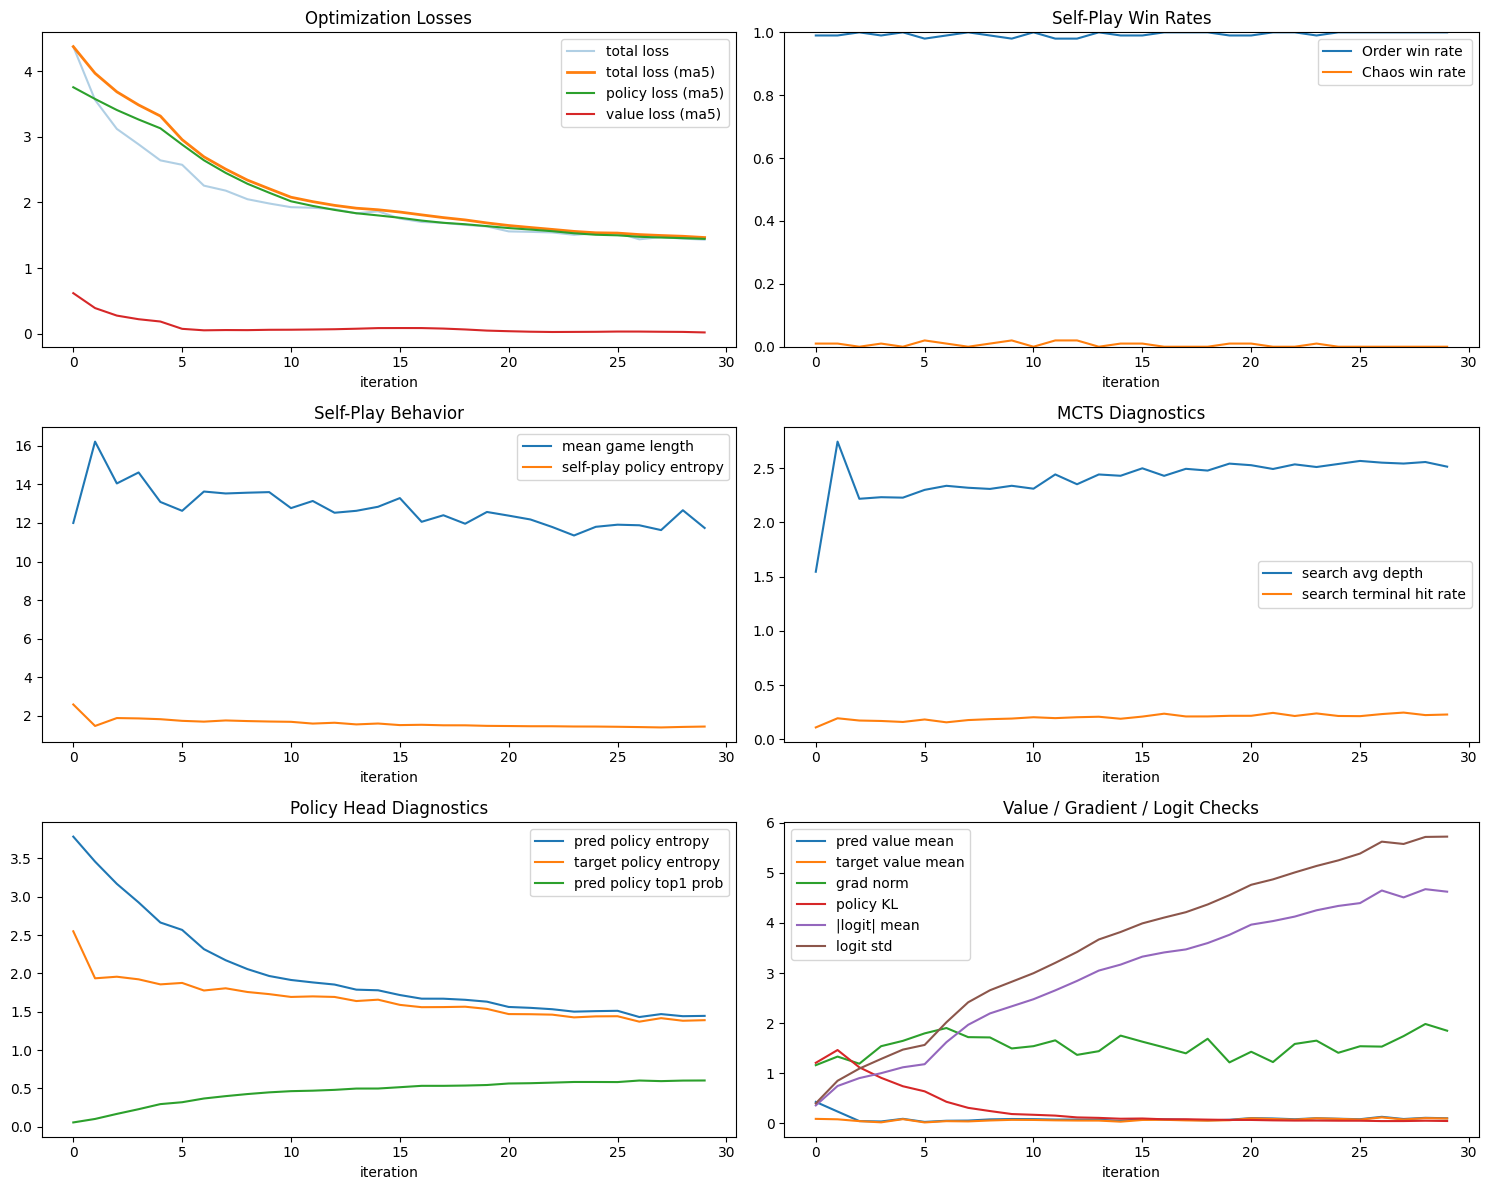

In [49]:
def moving_average(values, window=5):
    if len(values) == 0:
        return []
    out = []
    for idx in range(len(values)):
        start = max(0, idx - window + 1)
        out.append(float(np.mean(values[start:idx + 1])))
    return out

if len(iteration_metrics_history) == 0:
    raise RuntimeError("No iteration metrics found. Run the training loop cell first.")

iterations = [int(m["iteration"]) for m in iteration_metrics_history]
losses = [m["loss"] for m in iteration_metrics_history]
policy_losses = [m["policy_loss"] for m in iteration_metrics_history]
value_losses = [m["value_loss"] for m in iteration_metrics_history]
policy_kls = [m["policy_kl"] for m in iteration_metrics_history]
grad_norms = [m["grad_norm"] for m in iteration_metrics_history]
order_wins = [m["order_win_rate"] for m in iteration_metrics_history]
chaos_wins = [m["chaos_win_rate"] for m in iteration_metrics_history]
game_lengths = [m["mean_game_length"] for m in iteration_metrics_history]
selfplay_entropy = [m["mean_selfplay_policy_entropy"] for m in iteration_metrics_history]
search_depth = [m["mean_search_avg_depth"] for m in iteration_metrics_history]
search_terminal = [m["mean_search_terminal_hit_rate"] for m in iteration_metrics_history]
pred_top1 = [m["pred_policy_top1_prob"] for m in iteration_metrics_history]
target_entropy = [m["target_policy_entropy"] for m in iteration_metrics_history]
pred_entropy = [m["pred_policy_entropy"] for m in iteration_metrics_history]
pred_value_mean = [m["pred_value_mean"] for m in iteration_metrics_history]
target_value_mean = [m["target_value_mean"] for m in iteration_metrics_history]
logit_abs_mean = [m["policy_logit_abs_mean"] for m in iteration_metrics_history]
logit_std = [m["policy_logit_std"] for m in iteration_metrics_history]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

axes[0, 0].plot(iterations, losses, label="total loss", alpha=0.35)
axes[0, 0].plot(iterations, moving_average(losses, 5), label="total loss (ma5)", linewidth=2)
axes[0, 0].plot(iterations, moving_average(policy_losses, 5), label="policy loss (ma5)", linewidth=1.5)
axes[0, 0].plot(iterations, moving_average(value_losses, 5), label="value loss (ma5)", linewidth=1.5)
axes[0, 0].set_title("Optimization Losses")
axes[0, 0].legend()

axes[0, 1].plot(iterations, order_wins, label="Order win rate")
axes[0, 1].plot(iterations, chaos_wins, label="Chaos win rate")
axes[0, 1].set_ylim(0.0, 1.0)
axes[0, 1].set_title("Self-Play Win Rates")
axes[0, 1].legend()

axes[1, 0].plot(iterations, game_lengths, label="mean game length")
axes[1, 0].plot(iterations, selfplay_entropy, label="self-play policy entropy")
axes[1, 0].set_title("Self-Play Behavior")
axes[1, 0].legend()

axes[1, 1].plot(iterations, search_depth, label="search avg depth")
axes[1, 1].plot(iterations, search_terminal, label="search terminal hit rate")
axes[1, 1].set_title("MCTS Diagnostics")
axes[1, 1].legend()

axes[2, 0].plot(iterations, pred_entropy, label="pred policy entropy")
axes[2, 0].plot(iterations, target_entropy, label="target policy entropy")
axes[2, 0].plot(iterations, pred_top1, label="pred policy top1 prob")
axes[2, 0].set_title("Policy Head Diagnostics")
axes[2, 0].legend()

axes[2, 1].plot(iterations, pred_value_mean, label="pred value mean")
axes[2, 1].plot(iterations, target_value_mean, label="target value mean")
axes[2, 1].plot(iterations, grad_norms, label="grad norm")
axes[2, 1].plot(iterations, policy_kls, label="policy KL")
axes[2, 1].plot(iterations, logit_abs_mean, label="|logit| mean")
axes[2, 1].plot(iterations, logit_std, label="logit std")
axes[2, 1].set_title("Value / Gradient / Logit Checks")
axes[2, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("iteration")

plt.tight_layout()

last = iteration_metrics_history[-1]
print("Latest iteration diagnostics")
for key in [
    "loss",
    "policy_loss",
    "value_loss",
    "policy_kl",
    "grad_norm",
    "order_win_rate",
    "chaos_win_rate",
    "mean_game_length",
    "mean_search_avg_depth",
    "mean_search_terminal_hit_rate",
    "pred_policy_top1_prob",
    "policy_logit_std",
]:
    print(f"{key}: {last[key]:.6f}")


In [ ]:
# #retrain

# #Training loop

# NUM_ITERATIONS = 100
# BATCH_SIZE = 128
# MAX_BUFFER_SIZE = 35000
# SELF_PLAY_GAMES = 100
# SIMULATIONS_PER_MOVE = 400
# NUM_GRADIENT_STEPS = 70

# net = MaxwellsDemonNet()
# optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# for iteration in range(current_iteration, current_iteration + NUM_ITERATIONS):
#     print(f"\n=== Iteration {iteration} ===")

#     # --- Self-play ---
#     net.eval()
#     for g in range(SELF_PLAY_GAMES):
#         game_data = self_play_game(net, simulations=SIMULATIONS_PER_MOVE)
#         replay_buffer.extend(game_data)

#     # Trim buffer
#     if len(replay_buffer) > MAX_BUFFER_SIZE:
#         replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

#     print(f"Replay buffer size: {len(replay_buffer)}")

#     # --- Training ---
#     net.train()
#     losses = []

#     for _ in range(NUM_GRADIENT_STEPS):  #gradient steps per iteration
#         batch = random.sample(
#             replay_buffer,
#             min(BATCH_SIZE, len(replay_buffer))
#         )
#         loss = train_step(net, optimizer, batch)
#         losses.append(loss)

#     mean_loss_history[iteration + 1] = sum(losses)/len(losses)
#     print(f"Mean loss: {mean_loss_history[iteration + 1]:.4f}")
#     #checkpoint
#     if (iteration + 1) % 25 == 0:  # save every 25 iterations
#         print(f"Saving checkpoint at iteration {iteration + 1}...")
#         torch.save(
#             {
#                 "model_state_dict": net.state_dict(),
#                 "optimizer_state_dict": optimizer.state_dict(),
#                 "iteration": iteration + 1,
#                 "replay_buffer": replay_buffer,
#                 "mean_loss_history": mean_loss_history,
#             },
#             "maxwells_demon_checkpoint.pt",
#         )


In [55]:
# test model outputs for board states (raw net vs legal-masked net vs MCTS)

net.eval()

test_positions = [
    {
        "name": "Empty board, Order to move",
        "board": np.zeros((5, 5), dtype=np.int8),
        "player": 1,
    },
    {
        "name": "Near win pattern",
        "board": np.array([[1, -1, 0, 0, 0],
                           [0, 1, -1, 0, 0],
                           [0, 0, 1, -1, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8),
        "player": 1,
    },
    {
        "name": "Near loss / block test",
        "board": np.array([[0, 1, 1, 1, 0],
                           [-1, -1, -1, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8),
        "player": -1,
    },
    {
        "name": "Late-game chaos defense",
        "board": np.array([[ 1, 1, 1, 0,-1],
                           [-1,-1, -1, 1, 0],
                           [ 0, 1,-1, -1, 0],
                           [ 0, 0, 1, 1, 0],
                           [ 0, -1, 0, 1, 0]], dtype=np.int8),
        "player": -1,
    },
]

for i, case in enumerate(test_positions):
    game = OrderChaosGame()
    game.board = case["board"].copy()
    game.player = case["player"]

    state_tensor = torch.tensor(
        encode_state(game.board, game.get_current_player()),
        dtype=torch.float32,
    ).unsqueeze(0)

    with torch.no_grad():
        policy_logits, value = net(state_tensor)
        policy_probs = torch.softmax(policy_logits, dim=1).squeeze(0).cpu().numpy()

    legal = game.legal_actions()

    raw_best_idx = int(np.argmax(policy_probs))
    raw_best_legal = raw_best_idx in legal

    legal_scores = np.full_like(policy_probs, -np.inf)
    legal_scores[legal] = policy_probs[legal]
    legal_best_idx = int(np.argmax(legal_scores))

    top_k = min(5, len(legal))
    top_legal = sorted(legal, key=lambda a: policy_probs[a], reverse=True)[:top_k]

    root = MCTSNode(game.clone())
    visits = runMCTS(root, net, num_simulations=200)
    mcts_best_idx = max(visits.items(), key=lambda kv: kv[1])[0]

    print(f"Case {i}: {case['name']}")
    print(f"  value: {value.item():.4f}")
    print(f"  raw best:   {index_to_action(raw_best_idx)} prob={policy_probs[raw_best_idx]:.4f} legal={raw_best_legal}")
    print(f"  legal best: {index_to_action(legal_best_idx)} prob={policy_probs[legal_best_idx]:.4f}")
    print(f"  MCTS best:  {index_to_action(mcts_best_idx)} visits={visits[mcts_best_idx]}")
    print("  top legal by net:")
    for a in top_legal:
        print(f"    {index_to_action(a)} prob={policy_probs[a]:.4f}")
    print()


Case 0: Empty board, Order to move
  value: 1.0000
  raw best:   (4, 0, 1) prob=0.9986 legal=True
  legal best: (4, 0, 1) prob=0.9986
  MCTS best:  (4, 0, 1) visits=199
  top legal by net:
    (4, 0, 1) prob=0.9986
    (4, 1, -1) prob=0.0013
    (3, 3, -1) prob=0.0001
    (0, 3, -1) prob=0.0000
    (4, 1, 1) prob=0.0000

Case 1: Near win pattern
  value: 1.0000
  raw best:   (4, 0, 1) prob=0.9999 legal=True
  legal best: (4, 0, 1) prob=0.9999
  MCTS best:  (4, 0, 1) visits=199
  top legal by net:
    (4, 0, 1) prob=0.9999
    (3, 3, -1) prob=0.0001
    (0, 3, -1) prob=0.0000
    (2, 1, -1) prob=0.0000
    (3, 1, -1) prob=0.0000

Case 2: Near loss / block test
  value: -0.9947
  raw best:   (4, 0, 1) prob=0.2692 legal=True
  legal best: (4, 0, 1) prob=0.2692
  MCTS best:  (4, 0, 1) visits=57
  top legal by net:
    (4, 0, 1) prob=0.2692
    (2, 1, 1) prob=0.1677
    (2, 4, 1) prob=0.0571
    (3, 0, -1) prob=0.0560
    (3, 4, 1) prob=0.0513

Case 3: Late-game chaos defense
  value: -0.95

In [52]:
# Export to ONNX
net.eval()
net.cpu()

output_path = "../frontend/public/maxwells_demon.onnx"

class InferenceExportWrapper(nn.Module):
    def __init__(self, core_net):
        super().__init__()
        self.core_net = core_net

    def forward(self, board):
        policy_logits, value = self.core_net(board)
        policy_probs = torch.softmax(policy_logits, dim=1)
        return policy_probs, value

export_model = InferenceExportWrapper(net)

dummy_input = torch.zeros(
    1, 4, 5, 5,
    dtype=torch.float32
)

torch.onnx.export(
    export_model,
    dummy_input,
    output_path,
    input_names=["board"],
    output_names=["policy", "value"],
    dynamic_axes={
        "board": {0: "batch"},
        "policy": {0: "batch"},
        "value": {0: "batch"}
    },
    opset_version=17
)
